# Model ENSO full 12-2022

December 2022, January 2023, July 2024, May 2026

Caroline Juang, c.juang@columbia.edu

**After model training on `Model_ENSOclim_Akaike` and `Model_Akaike`, we use this file to input gSST and climate and output our estimates of area burned. For both gSST's influence on climate and climate's influence on area burned, we generate estimated annual area burned after adding the average of a 500-member ensemble of estimates in which our estimates of climate and log10(BA) are permuted by adding randomly drawn empirical values of Error.**

**Inputs:**
* SST gradient (1982-present) - build it following the README
* trained models `Model_ENSOclim_Akaike` (SST gradient -> climate)
* trained models `Model_Akaike` (climate -> burned area)

**Variables**
* `sstpred` generally refers to the detrended SST gradient, which is the detrended-SST gradient scenario put into the climate->burned area model.
* `climpred` generally refers to the observed SST gradient, put into the climate->burned area model.

**Outputs:**
* Predicted climate (1983-present) (but only for the relevant variables to the climate->burned area model)
* Predicted burned area (1984-present) from the trended and detrended scenarios into the climate->burned area model.
* Predicted burned area, detrended. `wumiDT`.

This model will predict burned area in ecoregions in the western US using seasonal SST gradient values.

In [1]:
# import

from customconfig import *
from customscripts import *

import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import pearsonr
import joblib

MANUALLY DEFINED, no forest models:
['ecoprov1', 'ecoprov3', 'ecoprov7', 'ecoprov18', 'ecoprov21']
MANUALLY DEFINED, no nonforest models:
[]
Ensemble is 500 members


In [2]:
# customize seasons for climate variables

# customize number of rolling periods
time_length = int(finalyear-firstyear+1) # get length of timeseries
# translate years into dates
firsttime = str(firstyear)+'-01-01'
finaltime = str(finalyear)+'-12-31'

# Read the climate index from the .txt file
with open('0_climindname.txt', 'r') as f:
    climindname = f.read().strip()
print(climindname +' will be used for the SST gradient')
climindnameDT = 'DeTrend_'+climindname
climfilename = 'DeTrendClimObs_'+climindname # sst-predicted BA

# importing data string
#data_string = 'data\\'
data_string = 'data//'
#model_string = 'model\\'+climindname+'//'
model_string = 'model//'+climindname+'//'
#predict_string = 'predicted\\'+climindname+'//'
predict_string = 'predicted//'+climindname+'//'

patch125-155_nino3-34 will be used for the SST gradient


## Import burned area data
from `Data_CreateModelData`

In [3]:
# import observed burned area
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')
print('imported '+filename+' all, for, non')

imported data//WUMI-ecoprovinces all, for, non


## Import observed SST gradient data
from `Data_CreateENSOIndex` and `Data_CreateModelData`

In [4]:
# import observed SST gradient
filename = data_string + 'sstgrad_seasons_' + climindname+'_82_y.txt'
climind82_seasons = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# import de-trended SST gradient
filename = data_string + 'sstgrad_seasons_' + climindnameDT+'_82_y.txt'
climind82_seasonsDT = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# import observed SST gradient (with extra year, for comparison)
filename = data_string + 'sstgrad_seasons_' + climindname+'_81_y.txt'
climind81_seasons = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# IMPORT gSST AVERAGE (average of concurrent-season and prior-season)
# import observed SST gradient
filename = data_string + 'sstgrad_seasons_' + climindname+'_82_y_avgcurr-prior.txt'
climind82_seasonsavg = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# import de-trended SST gradient
filename = data_string + 'sstgrad_seasons_' + climindnameDT+'_82_y_avgcurr-prior.txt'
climind82_seasonsDTavg = pd.read_csv(filename).set_index('Unnamed: 0')
print('imported '+filename)

# put the dataframes together
climind82_seasons = pd.concat([climind82_seasons, climind82_seasonsavg], axis=1)
climind82_seasonsDT = pd.concat([climind82_seasonsDT, climind82_seasonsDTavg], axis=1)

imported data//sstgrad_seasons_patch125-155_nino3-34_82_y.txt
imported data//sstgrad_seasons_DeTrend_patch125-155_nino3-34_82_y.txt
imported data//sstgrad_seasons_patch125-155_nino3-34_81_y.txt
imported data//sstgrad_seasons_patch125-155_nino3-34_82_y_avgcurr-prior.txt
imported data//sstgrad_seasons_DeTrend_patch125-155_nino3-34_82_y_avgcurr-prior.txt


## Import observed climate data
from `Data_CreateModelData`

In [5]:
# import OBSERVED climate data to feed into models
# climate is predicted using SST, but this is the climate observed data to check

dfframesall = {}
dfframesfor = {}
dfframesnon = {}

climind = pd.read_csv(data_string + 'gradient_'+climindname+'.txt', header=None, sep=",", skiprows=[0]).set_index(0)
for iecoreg in np.arange(len(province_num)):
    filename = data_string + 'climate_ecoprovinces_'
    print(dfnames[iecoreg])
    dfframesall[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_all.txt').set_index('Unnamed: 0')
    dfframesfor[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_for.txt').set_index('Unnamed: 0')
    dfframesnon[dfnames[iecoreg]] = pd.read_csv(filename + dfnames[iecoreg]+'_non.txt').set_index('Unnamed: 0')

allwestUS
ecoprov1
ecoprov2
ecoprov3
ecoprov4
ecoprov5
ecoprov6
ecoprov7
ecoprov8
ecoprov9
ecoprov10
ecoprov12
ecoprov13
ecoprov14
ecoprov15
ecoprov16
ecoprov17
ecoprov18
ecoprov19
ecoprov20
ecoprov21


## Import model outputs
from `Model_ENSOclim_Akaike` and `Model_Akaike`

In [6]:
# get the model input variable names from the txt files
# sst gradient to predict climate variables

with open(model_string + "modeloutput_sst_all_all.txt", "r") as f:
    inputsall = [line.strip() for line in f]
f.close()
with open(model_string + "modeloutput_sst_for.txt", "r") as f:
    inputsfor = [line.strip() for line in f]
f.close()
with open(model_string + "modeloutput_sst_non.txt", "r") as f:
    inputsnon = [line.strip() for line in f]
f.close()

# get indices of where each ecoregion's outputs begin
iinputsall = [i for i, e in 
               enumerate(inputsall) if "+++" in e]
# get ecoregions so iteration is not manual
iinputsfor = [i for i, e in 
               enumerate(inputsfor) if "+++" in e]
# get ecoregions so iteration is not manual
iinputsnon = [i for i, e in 
               enumerate(inputsnon) if "+++" in e]
# add in last index
iinputsall.append(len(inputsall)+1)
iinputsfor.append(len(inputsfor)+1)
iinputsnon.append(len(inputsnon)+1)

In [7]:
# get the model input variable names from the txt files
# climate variables to predict burned area

with open(model_string + "modeloutput_burnarea_for.txt", "r") as f:
    inputsfor_clim = [line.strip() for line in f]
f.close()
with open(model_string + "modeloutput_burnarea_non.txt", "r") as f:
    inputsnon_clim = [line.strip() for line in f]
f.close()

# get indices of where each ecoregion's outputs begin
# get ecoregions so iteration is not manual
iinputsfor_clim = [i for i, e in 
               enumerate(inputsfor_clim) if "+++" in e]
# get ecoregions so iteration is not manual
iinputsnon_clim = [i for i, e in 
               enumerate(inputsnon_clim) if "+++" in e]
# add in last index
iinputsfor_clim.append(len(inputsfor_clim)+1)
iinputsnon_clim.append(len(inputsnon_clim)+1)

# Setup for exporting burned area predictions

**500-member ensemble sequence of randomized years**
* `errormatrix` will be 500 x n-years time series of randomly-drawn years with replacement. This will be the same sequence used for both gSST-climate and climate-BA models.

**Predicted climate**
* SST_obs-predicted climate
* SST_neg-predicted climate
* difference between climate_sstobs and climate_sstneg, called climate_preddiff
* observed climate with climate_preddiff subtracted from it, called climate_sstdiff

**Predicted burned area**
* SST-predicted burned area (observed SST, goes through SST-clim and clim-BA models)
* climate-predicted burned area (observed climate, goes through clim-BA model)

In [8]:
# import the errormatrix (from Run_updateModel)
## use matrix of random years (n_years x n_ensemble members)
yearxaxis = np.arange(firstyear, finalyear+1)

tmp_fname = predict_string + "Model_ENSOFull_ErrorSequence.txt"
errormatrix = np.loadtxt(tmp_fname).astype(int) # load as integer

In [9]:
# print errormatrix to show the years
print(errormatrix[0:2,:]) # first three rows
print('\nshape: {:}'.format(np.shape(errormatrix)))

[[21  6  9  6 18 25 29 10 28  7 12 30 29 37 13 10 35  7 35 38 19 11 20  2
  13 11  7  3 18 26 29  6  2 31 16  4 20 38 33]
 [24 30  7 25 10 35  0  1 36 18 19  2  1 18 38 24  5 11 10 27 27 32  4 10
  17  8  2 14 19 36 32 27 31  6 15 21  9 29 19]]

shape: (500, 39)


In [10]:
# a bunch of dictionaries for storage
# predicted climate from observed SST
dfsstpredclimall_obsSST = {}
dfsstpredclimfor_obsSST = {}
dfsstpredclimnon_obsSST = {}

# predicted climate from negative-trended SST
dfsstpredclimall_negSST = {}
dfsstpredclimfor_negSST = {}
dfsstpredclimnon_negSST = {}

# difference in predicted climate scenarios, climate_preddiff
dfsstpredclimall_preddiff = {}
dfsstpredclimfor_preddiff = {}
dfsstpredclimnon_preddiff = {}

# observed climate minus climate_preddiff
dfsstpredclimall_sstdiff = {}
dfsstpredclimfor_sstdiff = {}
dfsstpredclimnon_sstdiff = {}

In [11]:
# a bunch of dictionaries for storage

# SST-predicted, from climate_sstdiff
dfsstpredBAall = []
dfsstpredBAfor = []
dfsstpredBAnon = []
# climate-predicted, from observed climate
dfclimpredBAall = []
dfclimpredBAfor = []
dfclimpredBAnon = []

# scripts

In [12]:
# get the SST inputs needed
def modelinputsst_string(inputlist, varname, istart, iend):
    """
    Requirements: 
    inputlist = list of the Model_ENSOclim_Akaike model results (locally defined)
    ithisecoreg = the ecoregion name (globally defined)
    ithisecoregend = the next ecoregion name 
        in the list (globally defined)
    varname = the climate variable name (locally defined)
    """
    # narrow inputs list to ecoregion
    modellist = inputlist[istart:iend+1]
    # get all PREDICTING (where inputs start)
    iinputs = [i for i, e in 
               enumerate(modellist) if "PREDICTING" in e]
    # extract model inputs
    istart = modellist.index('PREDICTING ' + varname)
    if len(iinputs)>((iinputs.index(istart))+1): # 
        iend = iinputs[(iinputs.index(istart))+1]
        modelinputs = modellist[istart+1:iend] # range in list
    else:
        modelinputs = modellist[istart+1:] # last predictor to end of list
    return modelinputs

In [13]:
# get the SST inputs needed
def sortInputStrings(inputlist, istart, iend):
    """
    Requirements: 
    inputlist = list of the Model_ENSOclim_Akaike model results (locally defined)
    istart = the ecoregion name
    iend = the next ecoregion name in the list
    """
    # narrow inputs list to ecoregion
    modellistsort = inputlist[istart+1:iend+1]
    # separate concurrent and previous-year variables
    modely0names = [s for s in modellistsort if "y0" in s]
    modely1names = [s for s in modellistsort if "y-1" in s]
    return [modellistsort, modely0names, modely1names]

In [14]:
def predictClimate(SSTgradient, y_perturbed_dict=None):
    """
    The goal is to predict all the climate variables used in the climate->burned
    area model, using our SST gradient->climate model, and put them in a 
    digestible format for inclusion in the climate->BA model/
    Inputs: seasonal variables 1983-present, in pandas DataFrame
        Plus requirements--which specify land type and ecoregion.
    Output: predictors for climate variable, in pandas DataFrame
    
    Requirements (a lot of variables):
        landname = should be 'all', 'for', or 'non'
    SST GRADIENT->CLIMATE MODEL: from imported TXT string of model variables.
        landtypeinput = Variable names, divided by ecoregion. For one land type.
        landtypeiinput = Locations (by line indices) of the start of variable names.
        ithisecoreg = Index of where ecoregion starts in list
        ithisecoregend = Index of where ecoregion ends in list
    CLIMATE->BURNED AREA MODEL: from imported TXT string of model variables.
        landtypeinputclim = Variable names, divided by ecoregion. For one land type.
        landtypeiinputclim = Locations (by line indices) of the start of variable names.
        ithisecoreg_clim = index of where ecoregion starts in list
        ithisecoregend_clim = index of where ecoregion ends in list
    sortInputStrings = script that intakes landtypeinputclim and outputs the same
        list but sorted into three buckets of the entire list (sorted, 
        y0 names, and y-1 names)

    y_perturbed_dict: if provided, dict of {climvar: synthetic_y_array}.
                      The model will be REFIT on this synthetic y instead
                      of loading the saved beta.
    """
    ecoregindex = dfnames.index(ecoregname)
    print('\nModeling the climate for '+landname+' in '+prov_abbr_names[ecoregindex])
    if not f.closed:
        writethis = prov_abbr_names[ecoregindex]+ ', ' +landname+':\n'
        f.write(writethis)
    # single-out the variables needed for the two models
    ithisecoreg = landtypeinput.index('+++'+ecoregname)
    ithisecoregend = landtypeiinput[landtypeiinput.index(ithisecoreg)+1]-1
    ithisecoreg_clim = landtypeinputclim.index('+++'+ecoregname)
    ithisecoregend_clim = landtypeiinputclim[landtypeiinputclim.index(ithisecoreg_clim)+1]-1
    [climnamessort, climy0names, climy1names] = sortInputStrings(landtypeinputclim,
                                                                ithisecoreg_clim, 
                                                                ithisecoregend_clim)
    
    # storage
    climmodeldict = {} # the loaded model
    climpred = [] # predicted climate variable values
    climnames = [] # name of climate variable
    
    # open models
    if len(climy0names)>0:
        for thisname in climy0names:
            filename = model_string + 'model_'+landname+'_'+thisname+'_'+ecoregname+'.sav'
            #print('\tLoading model: '+ filename)
            climmodeldict[thisname] = joblib.load(filename)
            # retrieve models
            modelinputs = modelinputsst_string(landtypeinput, thisname,
                                              ithisecoreg,
                                              ithisecoregend)
            #print('\tModel inputs: '+', '.join(modelinputs))
            # format the variable name for write to file
            tmpfullname, thisunits, thiscolor = suppclimplotformat(thisname)
            # get the column(s) of SST
            if len(modelinputs)==1:
                tmpX = np.asarray(SSTgradient[modelinputs]).reshape(-1,1)
            else:
                tmpX = np.asarray(SSTgradient[modelinputs])
            # predict climate, choose timeframe 1984 to present
            tmppred = climmodeldict[thisname].predict(tmpX).flatten()[1:].tolist()
            print('\t{:}_predicted = '.format(tmpfullname))
            if not f.closed:
                writethis = '{:}_predicted = '.format(tmpfullname)
                f.write(writethis)
            for thisvari, thisvarname in enumerate(modelinputs):
                tmpfullvarname, thisunits, thiscolor = suppclimplotformat('gsst '+thisvarname)
                print('\t+ {:.3f}({:})'.format(climmodeldict[thisname].coef_.flatten()[thisvari], tmpfullvarname))
                if not f.closed:
                    writethis = '+ {:.3f}({:}) '.format(climmodeldict[thisname].coef_.flatten()[thisvari], tmpfullvarname)
                    f.write(writethis)
            print('\t+ {:.3f}'.format(climmodeldict[thisname].intercept_.item()))
            if not f.closed:
                writethis = '+ {:.3f}\n'.format(climmodeldict[thisname].intercept_.item())
                f.write(writethis)
            climpred.append(tmppred)
            climnames.append(thisname)
            # correlation observed vs. predicted area
            if landname=='for':
                tmpobsclimate = dfframesfor[ecoregname][thisname]
            if landname=='non':
                tmpobsclimate = dfframesnon[ecoregname][thisname]
            tmpr = pearsonr(tmpobsclimate, np.array(tmppred).flatten())
            tmppmarker = addSigMarker(tmpr.pvalue)
            print('\t\tr-value(obs clim, pred clim): {:.2}{:}'.format(tmpr.statistic, 
                                                                      tmppmarker))
            if not f.closed:
                writethis = 'r(clim_obs, clim_pred): {:.2}{:}\n'.format(tmpr.statistic, 
                                                                        tmppmarker)
                f.write(writethis)

    if len(climy1names)>0:
        for thisname in climy1names:
            tmpfullname, thisunits, thiscolor = suppclimplotformat(thisname)
            filename = model_string + 'model_'+landname+'_'+thisname+'_'+ecoregname+'.sav'
            filename = filename.replace("y-1", "y0") # change to get model name
            tmpname = thisname.replace("y-1", "y0")
            #print('\tLoading model: '+ filename)
            climmodeldict[thisname] = joblib.load(filename)
            # retrieve models
            modelinputs = modelinputsst_string(landtypeinput, tmpname,
                                               ithisecoreg,
                                               ithisecoregend)
            #print('\tModel inputs: '+' '.join(modelinputs))
            # get the column(s) of SST
            if len(modelinputs)==1:
                tmpX = np.asarray(SSTgradient[modelinputs]).reshape(-1,1)
            else:
                tmpX = np.asarray(SSTgradient[modelinputs])
            # predict climate, choose timeframe 1983 to prior-year
            tmppred = climmodeldict[thisname].predict(tmpX).flatten()[:-1].tolist()
            print('\t{:}_predicted = '.format(tmpfullname))
            if not f.closed:
                writethis = '{:}_predicted = \n'.format(tmpfullname)
                f.write(writethis)
            for thisvari, thisvarname in enumerate(modelinputs):
                tmpfullvarname, thisunits, thiscolor = suppclimplotformat('gsst '+thisvarname)
                print('\t+ {:.3f}({:})'.format(climmodeldict[thisname].coef_.flatten()[thisvari], tmpfullvarname))
                if not f.closed:
                    writethis = '+ {:.3f}({:}) '.format(climmodeldict[thisname].coef_.flatten()[thisvari], tmpfullvarname)
                    f.write(writethis)
            print('\t\t+ {:.3f}'.format(climmodeldict[thisname].intercept_.item()))
            if not f.closed:
                writethis = '+ {:.3f}\n'.format(climmodeldict[thisname].intercept_.item())
                f.write(writethis)
            climpred.append(tmppred)
            climnames.append(thisname)
            # correlation observed vs. predicted area
            if landname=='for':
                tmpobsclimate = dfframesfor[ecoregname][thisname]
            if landname=='non':
                tmpobsclimate = dfframesnon[ecoregname][thisname]
            tmpr = pearsonr(tmpobsclimate, np.array(tmppred).flatten())
            tmppmarker = addSigMarker(tmpr.pvalue)
            print('\tr-value(obs clim, pred clim): {:.2}'.format(tmpr.statistic, tmppmarker))
            if not f.closed:
                writethis = 'r(clim_obs, clim_pred): {:.2}\n'.format(tmpr.statistic, tmppmarker)
                f.write(writethis)

    # create pandas dataframe to feed into prediction, sort
    climpred_T = np.array(climpred).transpose()
    Xclimpred = pd.DataFrame(climpred_T, index=None, columns=climnames).reindex(climnamessort, axis=1)    
    return Xclimpred

# SST -> climate

## observed SST by ecoregion

In [15]:
# write the same print statements to this file
modeloutputfile = 'Model_ENSOfull-outputsSST-Clim.txt'
f = open(modeloutputfile, 'w') # print to this file

# get this ecoregion
for ecoregname in dfnames:
    # FOREST import relevant models
    landname = 'for'
    landtypeinput = inputsfor
    landtypeiinput = iinputsfor
    landtypeinputclim = inputsfor_clim
    landtypeiinputclim = iinputsfor_clim

    # open models and predict climate
    Xclimpred = predictClimate(climind82_seasons)

    # save to dict
    dfsstpredclimfor_obsSST[ecoregname] = Xclimpred

    # NONFOREST import relevant models
    landname = 'non'
    landtypeinput = inputsnon
    landtypeiinput = iinputsnon
    landtypeinputclim = inputsnon_clim
    landtypeiinputclim = iinputsnon_clim

    # open models and predict climate
    Xclimpred = predictClimate(climind82_seasons)

    # save to dict
    dfsstpredclimnon_obsSST[ecoregname] = Xclimpred

f.close()


Modeling the climate for for in 0: All western US
	VPD y-0,JAS_predicted = 
	+ 0.000(gSST y-0,JAS)
	+ 0.000
		r-value(obs clim, pred clim): nan 
	VPD y-0,AMJ_predicted = 
	+ 0.510(gSST y-0,1-6)
	+ -1.213
		r-value(obs clim, pred clim): 0.38*
	Tmax y-0,OND_predicted = 
	+ 0.161(gSST y-0,OND)
	+ -0.633
		r-value(obs clim, pred clim): 0.23 

Modeling the climate for non in 0: All western US
	VPD y-0,JAS_predicted = 
	+ 0.455(gSST y-0,4-9)
	+ -1.220
		r-value(obs clim, pred clim): 0.35*
	Precipitation y-1,AMJ_predicted = 
	+ -0.401(gSST y-0,1-6)
		+ 0.954
	r-value(obs clim, pred clim): 0.33

Modeling the climate for for in 1: American Semi-Desert
	Precipitation y-1,JFM_predicted = 
	+ -0.607(gSST y-0,JFM)
		+ 1.538
	r-value(obs clim, pred clim): 0.64

Modeling the climate for non in 1: American Semi-Desert
	Tmax y-0,JAS_predicted = 
	+ 0.220(gSST y-0,JAS)
	+ -0.691
		r-value(obs clim, pred clim): 0.21 
	Precipitation y-1,OND_predicted = 
	+ -0.179(gSST y-0,OND)
		+ 0.702
	r-value(obs clim

/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.

## de-trended SST by ecoregion

In [16]:
for ecoregname in dfnames:

    # FOREST import relevant models
    landname = 'for'
    landtypeinput = inputsfor
    landtypeiinput = iinputsfor
    landtypeinputclim = inputsfor_clim
    landtypeiinputclim = iinputsfor_clim

    # open models and predict climate
    Xclimpred = predictClimate(climind82_seasonsDT)

    # save to dict
    dfsstpredclimfor_negSST[ecoregname] = Xclimpred

    # NONFOREST import relevant models
    landname = 'non'
    landtypeinput = inputsnon
    landtypeiinput = iinputsnon
    landtypeinputclim = inputsnon_clim
    landtypeiinputclim = iinputsnon_clim

    # open models and predict climate
    Xclimpred = predictClimate(climind82_seasonsDT)

    # save to dict
    dfsstpredclimnon_negSST[ecoregname] = Xclimpred


Modeling the climate for for in 0: All western US
	VPD y-0,JAS_predicted = 
	+ 0.000(gSST y-0,JAS)
	+ 0.000
		r-value(obs clim, pred clim): nan 
	VPD y-0,AMJ_predicted = 
	+ 0.510(gSST y-0,1-6)
	+ -1.213
		r-value(obs clim, pred clim): 0.25 
	Tmax y-0,OND_predicted = 
	+ 0.161(gSST y-0,OND)
	+ -0.633
		r-value(obs clim, pred clim): 0.12 

Modeling the climate for non in 0: All western US
	VPD y-0,JAS_predicted = 
	+ 0.455(gSST y-0,4-9)
	+ -1.220
		r-value(obs clim, pred clim): 0.14 
	Precipitation y-1,AMJ_predicted = 
	+ -0.401(gSST y-0,1-6)
		+ 0.954
	r-value(obs clim, pred clim): 0.31

Modeling the climate for for in 1: American Semi-Desert
	Precipitation y-1,JFM_predicted = 
	+ -0.607(gSST y-0,JFM)
		+ 1.538
	r-value(obs clim, pred clim): 0.61

Modeling the climate for non in 1: American Semi-Desert
	Tmax y-0,JAS_predicted = 
	+ 0.220(gSST y-0,JAS)
	+ -0.691
		r-value(obs clim, pred clim): 0.029 
	Precipitation y-1,OND_predicted = 
	+ -0.179(gSST y-0,OND)
		+ 0.702
	r-value(obs cli

/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.py:4781: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(msg))
/Users/caroline/Documents/GitHub/Project_ENSOFires_2022/Experimental Code/scikithere/lib/python3.11/site-packages/scipy/stats/_stats_py.

## calculate the gSST influence on climate ("sstdiff")

In [17]:
dfsstpredclimfor_sstdiff = {} # storage, different-sized pd dataframes for each ecoregion
dfsstpredclimnon_sstdiff = {}

# iterate through each ecoregion
for thisname in dfnames:
    # FOREST
    # get this ecoregion's predicted climate
    tmpsstobsclim = dfsstpredclimfor_obsSST[thisname]
    tmpsstnegclim = dfsstpredclimfor_negSST[thisname]
    tmpcols = tmpsstobsclim.columns
    tmpobsclim = dfframesfor[thisname][tmpcols]
    # take difference and add to dict
    tmppreddiff = tmpsstobsclim - tmpsstnegclim # diff in predictions
    tmpdiff = tmpobsclim - tmppreddiff # diff from obs
    dfsstpredclimfor_sstdiff[thisname] = tmpdiff
    
    # NONFOREST
    # get this ecoregion's predicted climate
    tmpsstobsclim = dfsstpredclimnon_obsSST[thisname]
    tmpsstnegclim = dfsstpredclimnon_negSST[thisname]
    tmpcols = tmpsstobsclim.columns
    tmpobsclim = dfframesnon[thisname][tmpcols]
    # take difference and add to dict
    tmppreddiff = tmpsstobsclim - tmpsstnegclim # diff in predictions
    tmpdiff = tmpobsclim - tmppreddiff # diff from obs
    dfsstpredclimnon_sstdiff[thisname] = tmpdiff

## add uncertainty from model residuals

The residuals of: observed climate minus the modeled climate from observed gSST, stored as `dfsstpredclimfor_obsresid` and `dfsstpredclimnon_obsresid`

In [18]:
# collect RESIDUALS from forest and non-forest and STORE
dfsstpredclimfor_obsresid = {}
dfsstpredclimnon_obsresid = {}
for thisname in dfnames:
    dfsstpredclimfor_obsresid[thisname] = {}
    dfsstpredclimnon_obsresid[thisname] = {}
    
    # FOREST
    # get this ecoregion's SST-obs-predicted climate
    tmpsstmodelclim = dfsstpredclimfor_obsSST[thisname] # FOREST

    # get this ecoregion's observed climate
    tmpcols = tmpsstmodelclim.columns
    tmpobsclim = dfframesfor[thisname][tmpcols] # FOREST

    # get residuals OBS
    tmpresid = tmpobsclim - tmpsstmodelclim # observed minus modeled
    dfsstpredclimfor_obsresid[thisname] = tmpresid # store residuals FOREST

    # NON-FOREST
    # get this ecoregion's SST-obs-predicted climate
    tmpsstmodelclim = dfsstpredclimnon_obsSST[thisname] # NON-FOREST

    # get this ecoregion's observed climate
    tmpcols = tmpsstmodelclim.columns
    tmpobsclim = dfframesnon[thisname][tmpcols] # NON-FOREST

    # get residuals OBS
    tmpresid = tmpobsclim - tmpsstmodelclim # observed minus modeled
    dfsstpredclimnon_obsresid[thisname] = tmpresid # store residuals NON-FOREST

### Set up for 500-member sstdiff plus uncertainty

(5/21/2026)

Setup for adding uncertainty in the climate-burned area model. Do not add residuals to each variable. Note that I set the line to: `tmpy_plus_err = tmpBA_dt.values - 0`


(4/16/2026)

For each ecoregion, for each variable: Add the 500-member residuals to each variable.

In [19]:
# add SSTDIFF and RESIDUALS!!!!!
# subtract the residuals because the equation is
# observed minus (sstdiff + residuals)
# NOTE: I REPLACED ALL RESIDUALS WITH ZEROS!!!! (5/20/2026)

# storage for clim with uncertainty
dfsstpredclimfor_sstdiff_plus_err = {} # FOREST store 500-member 
dfsstpredclimnon_sstdiff_plus_err = {} # NON-FOREST

# result is a dict that is ecoregion x years x every climate variablex500
for thisname in dfnames:
    # FOREST
    # load residuals
    tmpresids = dfsstpredclimfor_obsresid[thisname] # FOREST
    
    for tmpcol in tmpresids.columns.values:
        # load observed climate one variable
        tmpobsclim = dfframesfor[thisname][tmpcol] # FOREST
        # load observed-minus-sstdiff one column
        tmpBA_dt = dfsstpredclimfor_sstdiff[thisname][tmpcol] # FOREST
        
        # load 500-member residuals for one variable
        # HERE I SWITCHED OUT RESIDS FOR ZEROS !!!
        tmpresids[tmpcol] = np.zeros(np.shape(tmpresids[tmpcol]))
        tmpresids_filled = tmpresids[tmpcol].values[errormatrix]
        # add observed-minus-sstdiff MINUS residuals and into DataFrame
        tmpy_plus_err = tmpBA_dt.values - tmpresids_filled
        tmpcolnames = [f"{tmpcol}_{i}" for i in range(np.shape(tmpy_plus_err)[0])]
        tmpy_plus_err_df = pd.DataFrame(tmpy_plus_err.T, columns=tmpcolnames)
        
        # add the 500 members to the ecoregion df and STORE FOREST
        if thisname not in dfsstpredclimfor_sstdiff_plus_err:
            dfsstpredclimfor_sstdiff_plus_err[thisname] = tmpy_plus_err_df
        else:
            dfsstpredclimfor_sstdiff_plus_err[thisname] = pd.concat(
                [dfsstpredclimfor_sstdiff_plus_err[thisname], tmpy_plus_err_df],
                axis=1
            )
    # NON-FOREST
    # load residuals
    tmpresids = dfsstpredclimnon_obsresid[thisname] # NON-FOREST
    
    for tmpcol in tmpresids.columns.values:
        # load observed climate one variable
        tmpobsclim = dfframesnon[thisname][tmpcol] # NON-FOREST
        # load sstdiff one column
        tmpBA_dt = dfsstpredclimnon_sstdiff[thisname][tmpcol] # NON-FOREST
        
        # load 500-member residuals for one variable
        # HERE I SWITCHED OUT RESIDS FOR ZEROS !!!
        tmpresids[tmpcol] = np.zeros(np.shape(tmpresids[tmpcol]))
        tmpresids_filled = tmpresids[tmpcol].values[errormatrix]
        # add observed-minus-sstdiff MINUS residuals and into DataFrame
        tmpy_plus_err = tmpBA_dt.values - tmpresids_filled
        tmpcolnames = [f"{tmpcol}_{i}" for i in range(np.shape(tmpy_plus_err)[0])]
        tmpy_plus_err_df = pd.DataFrame(tmpy_plus_err.T, columns=tmpcolnames)
        
        # add the 500 members to the ecoregion df and STORE non-FOREST
        if thisname not in dfsstpredclimnon_sstdiff_plus_err:
            dfsstpredclimnon_sstdiff_plus_err[thisname] = tmpy_plus_err_df
        else:
            dfsstpredclimnon_sstdiff_plus_err[thisname] = pd.concat(
                [dfsstpredclimnon_sstdiff_plus_err[thisname], tmpy_plus_err_df],
                axis=1
            )

## export **"sstdiff_plus_err"** as **"sstpred_for"** climate without La Nina-like trend

In [20]:
# by ecoregion, export each of the climate observed-minus-sstdiff
for thisname in dfnames:
    dictoutputnames = 'sstpred_for'
    filename = predict_string + 'Climate_'+thisname+'_'+dictoutputnames+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
    dfsstpredclimfor_sstdiff_plus_err[thisname].to_csv(filename)
    dictoutputnames = 'sstpred_non'
    filename = predict_string + 'Climate_'+thisname+'_'+dictoutputnames+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
    dfsstpredclimnon_sstdiff_plus_err[thisname].to_csv(filename)

print('exported: '+ 'Climate_'+thisname+'_'+dictoutputnames+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt')

exported: Climate_ecoprov21_sstpred_non_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


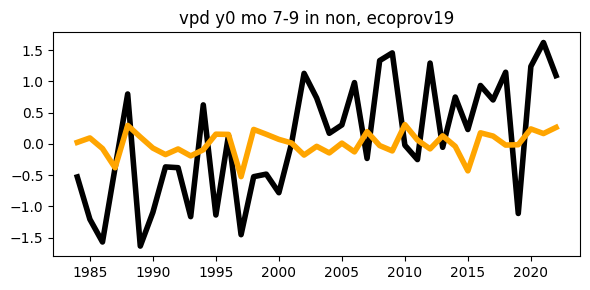

In [21]:
# plot one climate variable to show the difference between observed and
# model-predicted climate under observed gSST.

# all data
ecoregname = 'ecoprov19'
tmpcol = 'vpd y0 mo 7-9'
climcolobs = np.array(dfframesfor[ecoregname][tmpcol])
climcol_sstclimobs = dfsstpredclimfor_obsSST[ecoregname][tmpcol]
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, climcolobs, c='k', label='Observed climate', linewidth=4, zorder=4)
ax.plot(yearxaxis, climcol_sstclimobs, c='orange', linewidth=4, zorder=4)

ax.set_title(tmpcol + ' in '+landname + ', '+ ecoregname);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

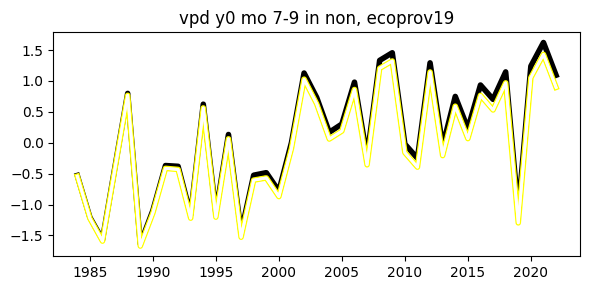

In [22]:
# plot one climate variable to show the residuals

# all data
ecoregname = 'ecoprov19'
tmpcol = 'vpd y0 mo 7-9'
climcolobs = np.array(dfframesfor[ecoregname][tmpcol])
climcol_sstdt = dfsstpredclimfor_sstdiff[ecoregname][tmpcol]
climcol_pluserr = dfsstpredclimfor_sstdiff_plus_err[ecoregname].filter(like=tmpcol)
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, climcolobs, c='k', label='Observed climate', linewidth=4, zorder=4)
ax.plot(yearxaxis, climcol_sstdt, c='yellow', linewidth=4, zorder=4)
ax.plot(yearxaxis, climcol_pluserr, label='climate plus sst uncertainty')
ax.plot(yearxaxis, climcol_pluserr.quantile(0.05, axis=1), 
        label='climate 5th percent', c='white', linewidth=2, zorder=4)
ax.plot(yearxaxis, climcol_pluserr.quantile(0.95, axis=1),
        label='climate 95th percent', c='white', linewidth=2, zorder=4)

ax.set_title(tmpcol + ' in '+landname + ', '+ ecoregname);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

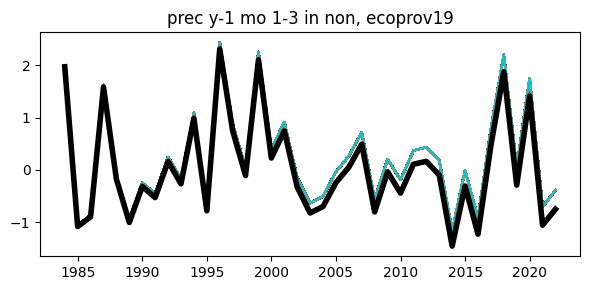

In [23]:
# plot one climate variable to show the residuals

# all data
ecoregname = 'ecoprov19'
tmpcol = 'prec y-1 mo 1-3'
climcolobs = np.array(dfframesnon[ecoregname][tmpcol])
climcol_pluserr = dfsstpredclimnon_sstdiff_plus_err[ecoregname].filter(like=tmpcol)
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, climcolobs, c='k', label='Observed climate', linewidth=4, zorder=4)
ax.plot(yearxaxis, climcol_pluserr, label='climate plus sst uncertainty')
ax.set_title(tmpcol + ' in '+landname + ', '+ ecoregname);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

# Predicted Burned Area

Iterate through each ecoprovince by `ecoregname` and `iecoreg`, calculate the predicted burned area based on the observed climate `dfclimpredBA` and based on the SST difference `dfsstpredBA`.

In [24]:
# PREDICT AREA BURNED
# SST-predicted, from climate_sstdiff
dfsstpredBAall = [] # will be 500*21 x 39
dfsstpredBAfor = []
dfsstpredBAnon = []
# climate-predicted, from observed climate
dfclimpredBAall = [] # will be 21 x 39
dfclimpredBAfor = []
dfclimpredBAnon = []
burnareapredloop = [] # column names storage

# write the same print statements to this file
modeloutputfile = 'Model_ENSOfull-outputsClim-BA.txt'
f = open(modeloutputfile, 'w') # print to this file
import warnings
warnings.filterwarnings('ignore')

# get this ecoregion
for thisi, thisname in enumerate(dfnames):
    ecoregname = thisname
    print(ecoregname)
    iecoreg = thisi

    ###########

    landname = 'for'
    # finalclimpred is fed into the burned area model
    filename = model_string + 'model_'+landname+'_burnedarea_'+ecoregname+'.sav'
    modelburnarea = joblib.load(filename)
    
    # grab the original column names using original SSTdiff, get cols
    climnamessort = dfsstpredclimfor_sstdiff[thisname].columns.values # FOREST
    print(prov_abbr_names[thisi] + ' - FOREST BA-model vars: ')
    f.write(prov_abbr_names[thisi] + ' - FOREST: \n')
    print('log10(BA) = ')
    f.write('log10(BA) = \n')
    # grab the observed data, predict area burned
    Xclimpredobs = dfframesfor[ecoregname][climnamessort]
    tmpvariableeq = dfframesfor[ecoregname][climnamessort].columns.values
    for thisvari, thisvarname in enumerate(tmpvariableeq):
        tmpfullname, thisunits, thiscolor = suppclimplotformat(thisvarname)
        print('+ {:.3f}({:}) '.format(modelburnarea.coef_[thisvari], tmpfullname))
        f.write('+ {:.3f}({:}) '.format(modelburnarea.coef_[thisvari], tmpfullname))
    print('+ {:.3f} + \u03B5\n'.format(modelburnarea.intercept_))
    f.write('+ {:.3f} + \u03B5\n'.format(modelburnarea.intercept_))
    burnareapredobs = modelburnarea.predict(Xclimpredobs)
    
    # SAVE THE OUTPUT
    dfclimpredBAfor.append(burnareapredobs) # obsclim-predicted BA

    for k in np.arange(0,np.shape(errormatrix)[0]):
        # get all the climate members for k
        tmpcolmem = []
        for tmpcol in climnamessort:
            tmpcolmem.append(tmpcol + '_' + str(k)) # member k climate
        # grab the adjusted climate predictions, predict area burned
        Xclimpred = dfsstpredclimfor_sstdiff_plus_err[ecoregname][tmpcolmem] # FOREST
        # rename columns to match the BA model
        Xclimpred.columns = climnamessort
        # predict BA
        burnareapred = modelburnarea.predict(Xclimpred)
        namepredloop = thisname + '_' + str(k) # ecoprovince_k
        burnareapredloop.append(namepredloop) # append column NAME!!!!

        # SAVE the predicted outputs
        dfsstpredBAfor.append(burnareapred) # append SST-predicted BA

    # all data
    #wumicol = np.array(wumifor.iloc[:,iecoreg])
    #fig, ax = plt.subplots(figsize=(6,3))
    #ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
    #ax.plot(yearxaxis, 10**burnareapredobs, label='From climate, observed')
    #ax.plot(yearxaxis, 10**burnareapred, label='From climate, no SST trend')
    #ax.legend()
    #tmpcorr = pearsonr(burnareapredobs, burnareapred)
    #ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
    #fig.tight_layout()
    #plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')
    #plt.close()
    
    ###########

    landname = 'non'

    # finalclimpred is fed into the burned area model
    filename = model_string + 'model_'+landname+'_burnedarea_'+ecoregname+'.sav'
    modelburnarea = joblib.load(filename)
    
    # grab the original column names using original SSTdiff, get cols
    climnamessort = dfsstpredclimnon_sstdiff[thisname].columns.values # NON-FOREST
    print(prov_abbr_names[thisi] + ' - NON-FOREST BA-model vars: ')
    f.write(prov_abbr_names[thisi] + ' - NON-FOREST: \n')
    print('log10(BA) = ')
    f.write('log10(BA) = \n')
    # grab the observed data, predict area burned
    Xclimpredobs = dfframesnon[ecoregname][climnamessort]
    tmpvariableeq = dfframesnon[ecoregname][climnamessort].columns.values
    for thisvari, thisvarname in enumerate(tmpvariableeq):
        tmpfullname, thisunits, thiscolor = suppclimplotformat(thisvarname)
        print('+ {:.3f}({:}) '.format(modelburnarea.coef_[thisvari], tmpfullname))
        f.write('+ {:.3f}({:}) '.format(modelburnarea.coef_[thisvari], tmpfullname))
    print('+ {:.3f} + \u03B5\n'.format(modelburnarea.intercept_))
    f.write('+ {:.3f} + \u03B5\n'.format(modelburnarea.intercept_))
    burnareapredobs = modelburnarea.predict(Xclimpredobs)
    
    # SAVE THE OUTPUT
    dfclimpredBAnon.append(burnareapredobs) # obsclim-predicted BA

    for k in np.arange(0,np.shape(errormatrix)[0]):
        # get all the climate members for k
        tmpcolmem = []
        for tmpcol in climnamessort:
            tmpcolmem.append(tmpcol + '_' + str(k)) # member k climate
        # grab the adjusted climate predictions, predict area burned
        Xclimpred = dfsstpredclimnon_sstdiff_plus_err[ecoregname][tmpcolmem] # NON-FOREST
        # rename columns to match the BA model
        Xclimpred.columns = climnamessort
        # predict BA
        burnareapred = modelburnarea.predict(Xclimpred)

        # SAVE the predicted outputs
        dfsstpredBAnon.append(burnareapred) # append SST-predicted BA

    # all data
    wumicol = np.array(wuminon.iloc[:,iecoreg])
    fig, ax = plt.subplots(figsize=(6,3))
    yearxaxis = np.arange(firstyear, finalyear+1)
    ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
    ax.plot(yearxaxis, 10**burnareapredobs, label='From climate, observed')
    ax.plot(yearxaxis, 10**burnareapred, label='From climate, no SST trend')
    ax.legend()
    tmpcorr = pearsonr(burnareapredobs, burnareapred)
    ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
    fig.tight_layout()
    #plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')
    plt.close()
    ############

landname = 'all'

# instead of using model, we sum forest+nonforest predictions in the ecoprovince
# SAVE the predicted outputs
dfsstpredBAall = np.log10((10**np.array(dfsstpredBAfor))+(10**np.array(dfsstpredBAnon)))
dfclimpredBAall = np.log10((10**np.array(dfclimpredBAfor))+(10**np.array(dfclimpredBAnon)))

# all data
#wumicol = np.array(wumi.iloc[:,iecoreg])
#fig, ax = plt.subplots(figsize=(6,3))
#yearxaxis = np.arange(firstyear, finalyear+1)
#ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area')
#ax.plot(yearxaxis, 10**burnareapredobs, label='From climate, observed')
#ax.plot(yearxaxis, 10**burnareapred, label='From climate, no SST trend')
#ax.legend()
#tmpcorr = pearsonr(burnareapredobs, burnareapred)
#ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
#fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+'for+non'+'_'+ecoregname+'_BurnAreaPred')
#plt.close()

# close file
f.close()

allwestUS
0: All western US - FOREST BA-model vars: 
log10(BA) = 
+ 0.287(VPD y-0,JAS) 
+ 0.207(VPD y-0,AMJ) 
+ 0.112(Tmax y-0,OND) 
+ 3.392 + ε

0: All western US - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.150(VPD y-0,JAS) 
+ 0.122(Precipitation y-1,AMJ) 
+ 3.695 + ε



ecoprov1
1: American Semi-Desert - FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Precipitation y-1,JFM) 
+ 1.103 + ε

1: American Semi-Desert - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.222(Precipitation y-1,OND) 
+ 0.180(Precipitation y-1,JFM) 
+ 0.115(Tmax y-0,JAS) 
+ 2.038 + ε



ecoprov2
2: AZ-NM Mountains - FOREST BA-model vars: 
log10(BA) = 
+ 0.262(VPD y-0,AMJ) 
+ 0.245(Tmax y-0,JAS) 
+ 2.284 + ε

2: AZ-NM Mountains - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.315(Wind y-0,JFM) 
+ 0.814(Tmax y-0,JAS) 
+ 0.647(Wet_days y-0,JAS) 
+ 0.286(Precipitation y-1,AMJ) 
+ 1.431 + ε



ecoprov3
x: Black Hills Coniferous Forest - FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Precipitation y-0,AMJ) 
+ 0.322 + ε

x: Black Hills Coniferous Forest - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Precipitation y-1,JFM) 
+ -1.234 + ε



ecoprov4
3: CA Coast Chapparral Forest - FOREST BA-model vars: 
log10(BA) = 
+ 0.347(VPD y-0,OND) 
+ 0.154 + ε

3: CA Coast Chapparral Forest - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.311(VPD y-0,OND) 
+ 1.846 + ε



...

ecoprov17
14: Northern Rocky Mountain Forest - FOREST BA-model vars: 
log10(BA) = 
+ 0.609(VPD y-0,JAS) 
+ 0.194(VPD y-0,AMJ) 
+ 1.825 + ε

14: Northern Rocky Mountain Forest - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.392(VPD y-0,JAS) 
+ -0.274(Precipitation y-1,JAS) 
+ 0.201(VPD y-0,JFM) 
+ 1.430 + ε



ecoprov18
x: Pacific Lowland Mixed Forest Province - FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Tmax y-0,OND) 
+ -0.416 + ε

x: Pacific Lowland Mixed Forest Province - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Wet_days y-0,JAS) 
+ -1.049 + ε



ecoprov19
15: Sierran Steppe - FOREST BA-model vars: 
log10(BA) = 
+ 0.369(VPD y-0,JAS) 
+ 0.314(Tmax y-0,AMJ) 
+ 0.171(Precipitation y-1,JFM) 
+ 0.168(VPD y-0,OND) 
+ 2.595 + ε

15: Sierran Steppe - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.211(Precipitation y-1,JFM) 
+ 0.192(VPD y-0,AMJ) 
+ 0.125(VPD y-0,OND) 
+ 2.251 + ε



ecoprov20
16: Southern Rocky Mountain Steppe - FOREST BA-model vars: 
log10(BA) = 
+ 0.615(VPD y-0,JAS) 
+ 0.255(Solar_radiation y-0,JFM) 
+ 0.135(Wind y-0,JFM) 
+ 2.093 + ε

16: Southern Rocky Mountain Steppe - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.363(VPD y-0,AMJ) 
+ 0.169(Solar_radiation y-0,JAS) 
+ 1.770 + ε



ecoprov21
17: SW Plateau and Plains - FOREST BA-model vars: 
log10(BA) = 
+ 0.000(Tmax y-0,JFM) 
+ -1.459 + ε

17: SW Plateau and Plains - NON-FOREST BA-model vars: 
log10(BA) = 
+ 0.482(Precipitation y-1,JAS) 
+ 0.282(Wind y-0,JFM) 
+ 0.257(Precipitation y-1,JFM) 
+ 0.314(Solar_radiation y-0,OND) 
+ 0.252(Precipitation y-1,AMJ) 
+ 1.712 + ε



## set Ecoprovince 0 (all west US) as sum of the ecoprovinces

In [25]:
# make pandas df at this point
dfsstpredBAall_df = pd.DataFrame(np.transpose(np.stack(dfsstpredBAall)), # sst-pred 
                                 columns=[burnareapredloop], index=yearxaxis)
dfsstpredBAfor_df = pd.DataFrame(np.transpose(np.stack(dfsstpredBAfor)), 
                                 columns=[burnareapredloop], index=yearxaxis)
dfsstpredBAnon_df = pd.DataFrame(np.transpose(np.stack(dfsstpredBAnon)), 
                                 columns=[burnareapredloop], index=yearxaxis)
dfclimpredBAall_df = pd.DataFrame(np.transpose(np.stack(dfclimpredBAall)), # obsclim-pred
                                 columns=[dfnames], index=yearxaxis)
dfclimpredBAfor_df = pd.DataFrame(np.transpose(np.stack(dfclimpredBAfor)), 
                                 columns=[dfnames], index=yearxaxis)
dfclimpredBAnon_df = pd.DataFrame(np.transpose(np.stack(dfclimpredBAnon)), 
                                 columns=[dfnames], index=yearxaxis)

In [26]:
# SUM ECOPROVINCES FOR ALL WESTERN US
# make everything unlogged
# then sum the burned area from all ecoprovinces
# then log it again, and set the first ecoprovince as the sums

# sst-pred
for k in range(500):
    # select all ecoprov columns for this k; FOREST + NONFOREST
    cols_k = [c for c in burnareapredloop if c.endswith(f"_{k}") and "ecoprov" in c]
    # log10 to linear
    tmplinearBA = 10 ** dfsstpredBAall_df[cols_k]
    # sum across ecoprovinces (axis=1 = across columns)
    tmpsummed = tmplinearBA.sum(axis=1)
    # back to log10
    dfsstpredBAall_df[f"allwestUS_{k}"] = np.log10(tmpsummed)

    # FOREST
    cols_k = [c for c in burnareapredloop if c.endswith(f"_{k}") and "ecoprov" in c]
    # log10 to linear
    tmplinearBA = 10 ** dfsstpredBAfor_df[cols_k]
    # sum across ecoprovinces (axis=1 = across columns)
    tmpsummed = tmplinearBA.sum(axis=1)
    # back to log10
    dfsstpredBAfor_df[f"allwestUS_{k}"] = np.log10(tmpsummed)

    # NON-FOREST
    cols_k = [c for c in burnareapredloop if c.endswith(f"_{k}") and "ecoprov" in c]
    # log10 to linear
    tmplinearBA = 10 ** dfsstpredBAnon_df[cols_k]
    # sum across ecoprovinces (axis=1 = across columns)
    tmpsummed = tmplinearBA.sum(axis=1)
    # back to log10
    dfsstpredBAnon_df[f"allwestUS_{k}"] = np.log10(tmpsummed)

# clim-pred
tmplinearBA = 10**dfclimpredBAall_df # unlog
dfclimpredBAall_df['allwestUS'] = np.log10((tmplinearBA.iloc[:,1:]).sum(axis=1)) # re-log

tmplinearBA = 10**dfclimpredBAfor_df # unlog
dfclimpredBAfor_df['allwestUS'] = np.log10((tmplinearBA.iloc[:,1:]).sum(axis=1)) # re-log

tmplinearBA = 10**dfclimpredBAnon_df # unlog
dfclimpredBAnon_df['allwestUS'] = np.log10((tmplinearBA.iloc[:,1:]).sum(axis=1)) # re-log

## Calculate full WUMI without SST gradient trend (DT scenario)

outputted as `BurnArea_wumiDT`

In [27]:
counter = 0 # for wumi
wumiallDT = []
wumiforDT = []
wuminonDT = []

for thisname in dfnames:
    # grab values
    tmpBA = wumi[str(counter)].values
    tmpBAfor = wumifor[str(counter)].values
    tmpBAnon = wuminon[str(counter)].values
    tmpBAclim = 10**dfclimpredBAall_df[thisname].values.flatten() # unlog
    tmpBAclimfor = 10**dfclimpredBAfor_df[thisname].values.flatten()
    tmpBAclimnon = 10**dfclimpredBAnon_df[thisname].values.flatten()
    # grab values
    for k in range(500):
        # select ecoprovince + k
        thisnamek = thisname +'_'+str(k)
        tmpBAsst = 10**dfsstpredBAall_df[thisnamek].values.flatten() # unlog
        tmpBAsstfor = 10**dfsstpredBAfor_df[thisnamek].values.flatten()
        tmpBAsstnon = 10**dfsstpredBAnon_df[thisnamek].values.flatten()

        # calculate the full BA without SST gradient trend influence
        # observed BA - (observed SST in clim-BA model BA - DT SST clim-BA model BA)
        tmpBAnosst = tmpBA - (tmpBAclim - tmpBAsst)
        tmpBAnosstfor = tmpBAfor - (tmpBAclimfor - tmpBAsstfor)
        tmpBAnosstnon = tmpBAnon - (tmpBAclimnon - tmpBAsstnon)

        wumiallDT.append(tmpBAnosst)
        wumiforDT.append(tmpBAnosstfor)
        wuminonDT.append(tmpBAnosstnon)

# transform into pandas dataframe
wumiallDT = pd.DataFrame(np.transpose(np.stack(wumiallDT)),
                         columns=[burnareapredloop], index=yearxaxis)
wumiforDT = pd.DataFrame(np.transpose(np.stack(wumiforDT)),
                         columns=[burnareapredloop], index=yearxaxis)
wuminonDT = pd.DataFrame(np.transpose(np.stack(wuminonDT)),
                         columns=[burnareapredloop], index=yearxaxis)

# Export predicted burned area data
The filename of the data will change with the type of SST and landcover type used in the models. Data will export for all ecoregions.

In [28]:
dictoutputs = [dfsstpredBAall_df, dfsstpredBAfor_df, dfsstpredBAnon_df,
               dfclimpredBAall_df, dfclimpredBAfor_df, dfclimpredBAnon_df,
               wumiallDT, wumiforDT, wuminonDT]
dictoutputnames = ['sstpred_all', 'sstpred_for', 'sstpred_non',
                   'climpred_all','climpred_for','climpred_non',
                   'wumiDT_all', 'wumiDT_for', 'wumiDT_non']

# convert to pandas df and export
for i,thisdict in enumerate(dictoutputs):
    tmpoutput = thisdict
    if i<3: # export the SST-predicted
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    if (i>=3) & (i<6): # export the climate-predicted
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    if (i>=6): # export the detrended wumi
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    print('Exported: '+filename)

Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_all_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_for_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_non_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_all_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_for_1984-2022.txt
Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_non_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_wumiDT_all_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_wumiDT_for_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_wumiDT_non_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


## Ecoregion 0 burned area (summed from all ecoregions)

### all

In [29]:
# import the file
climfilename = 'DeTrendClimObs_'+climindname # same as Model_ENSOfull

# import DETRENDED burned area wumi
filename = predict_string + 'BurnArea_wumiDT'
filenameend = '_'+str(firstyear)+'-'+str(finalyear)+'.txt'
wumiDT = pd.read_csv(filename+'_all_'+climfilename+filenameend).set_index('Unnamed: 0')
wumiforDT = pd.read_csv(filename+'_for_'+climfilename+filenameend).set_index('Unnamed: 0')
wuminonDT = pd.read_csv(filename+'_non_'+climfilename+filenameend).set_index('Unnamed: 0')

# PREDICTED BURNED AREA from observed SST and observed climate 
# (Model_ENSOfull12-2022 must be updated)

#filename = predict_string + 'BurnArea_'
filename = predict_string + 'BurnArea_'

# predicted burned area from observed climate
BAclimpredall = pd.read_csv(filename+'climpred_all_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor = pd.read_csv(filename+'climpred_for_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon = pd.read_csv(filename+'climpred_non_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

# predicted burned area removing SST gradient trend
# (observed climate - climate without effect of SST trend)
BAclimpredall_DT = pd.read_csv(filename+'sstpred_all_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor_DT = pd.read_csv(filename+'sstpred_for_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon_DT = pd.read_csv(filename+'sstpred_non_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')


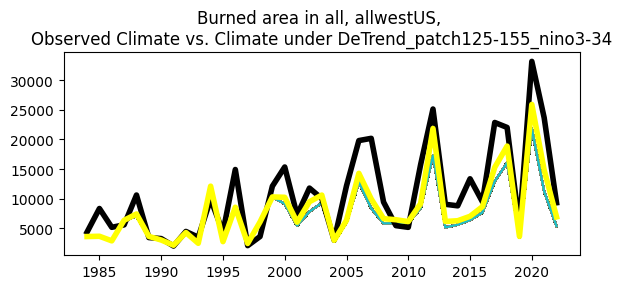

In [30]:
# all data
landname = 'all'
iecoreg = '0'
ecoregname = 'allwestUS'
wumicol = np.array(wumi.loc[:,iecoreg])
tmpdf_2 = 10**BAclimpredall[ecoregname]
tmpdf_3 = 10**BAclimpredall_DT.filter(like=ecoregname)
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_2, c='yellow', label='From climate, observed', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_3, label='From climate, no SST trend')
#ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

### forest

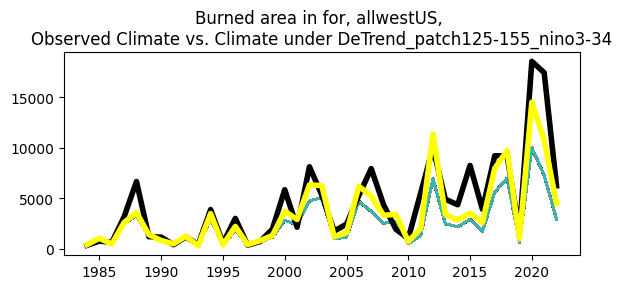

In [31]:
# all data
landname = 'for'
iecoreg = '0'
ecoregname = 'allwestUS'
wumicol = np.array(wumifor.loc[:,iecoreg])
tmpdf_2 = 10**BAclimpredfor[ecoregname]
tmpdf_3 = 10**BAclimpredfor_DT.filter(like=ecoregname)
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_2, c='yellow', label='From climate, observed', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_3, label='From climate, no SST trend')
#ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

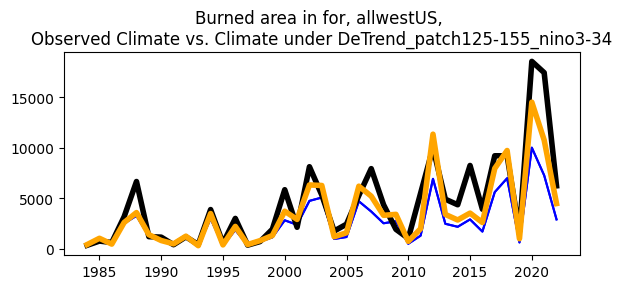

In [32]:
# just plot data within 95th confidence intervals on predicted area burned

# all data
landname = 'for'
iecoreg = '0'
ecoregname = 'allwestUS'
wumicol = np.array(wumifor.loc[:,iecoreg])
tmpdf_2 = 10**BAclimpredfor[ecoregname]
tmpdf_3 = 10**(BAclimpredfor_DT.filter(like=ecoregname).quantile(0.05, axis=1))
tmpdf_4 = 10**(BAclimpredfor_DT.filter(like=ecoregname).quantile(0.95, axis=1))
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_2, c='orange', label='From climate, observed', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_3, c='blue', label='From climate, no SST trend 5%')
ax.plot(yearxaxis, tmpdf_4, c='blue', label='From climate, no SST trend 95%')
#ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

### nonforest

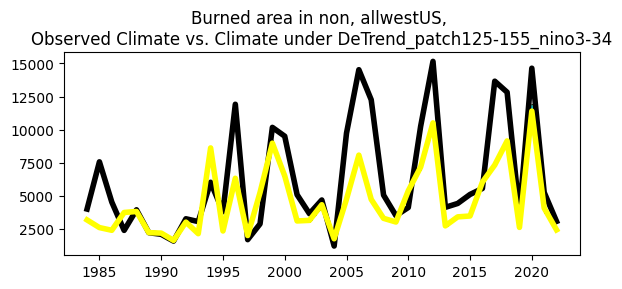

In [33]:
# all data
landname = 'non'
iecoreg = '0'
ecoregname = 'allwestUS'
wumicol = np.array(wuminon.loc[:,iecoreg])
tmpdf_2 = 10**BAclimprednon[ecoregname]
tmpdf_3 = 10**BAclimprednon_DT.filter(like=ecoregname)
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_2, c='yellow', label='From climate, observed', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_3, label='From climate, no SST trend')
#ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

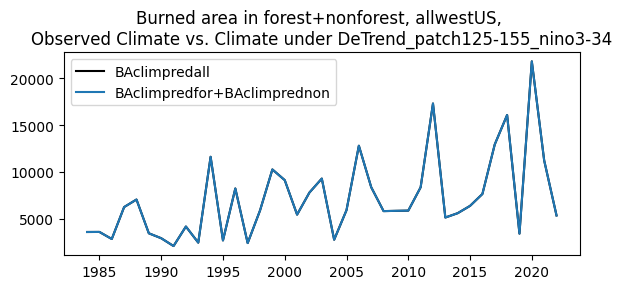

In [34]:
# forest+nonforest
# check that the forest+nonforest math aligns with the "all" 
fig, ax = plt.subplots(figsize=(6,3))
tmpdf_1 = 10**(BAclimpredall_DT.filter(like=ecoregname)).iloc[:,0]
tmpdf_2 = 10**(BAclimpredfor_DT.filter(like=ecoregname)).iloc[:,0]
tmpdf_3 = 10**(BAclimprednon_DT.filter(like=ecoregname)).iloc[:,0]

yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, tmpdf_1, c='k', label='BAclimpredall')
ax.plot(yearxaxis, tmpdf_2 + tmpdf_3, label='BAclimpredfor+BAclimprednon')
ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in forest+nonforest, '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+'for+non'+'_'+ecoregname+'_BurnAreaPred')

# Ensemble Error

Replaces the current `wumifor`, `wuminon`, `dfclimpredBAfor`, and `dfclimpredBAnon`

September 4, 2024

Because our model predicts log10(BA), it is prone to errors at higher burned area values. In general, by predicting log10(BA), our model will tend to underestimate . When we take the mean of log10(BA) for the entire timeseries, then the mean would be an underestimate of the actual mean. (the mean of 10^1, 10^2, and 10^3 would be (1+2+3)/3, which is 2, but that would be 100. But the real average would be 370.

* BA_mod = modeled burned area
* BA_obs = observed burned area

Method is as follows:
1. Calculate the time series of errors `BA_error_log10 = log10(BA_obs) - log10(BA_mod)`
3. make an ensemble of 500 time series of `log10(BA_mod_plus_error)`.
    * for each step in the time series of `BA_mod`, the error is randomly selected and added to the step in the time series by sampling from the time series of `BA_error_log10` with replacement, not including sampling from the index year being selected for.
    * Result is one 39x500 matrix (years x ensembles) of randomly-selected years is created, and used to pick for all of the ecoprovinces and timeseries at once.
4. Un-log all 500 time series of log10(BA_mod_plus_error) to get the 500-member ensemble in original km^2 units.
5. Convert negative values to 0 km^2
6. Take the average of all 500 time series.

In [35]:
# import OBSERVED burned area wumi
filename = data_string + 'WUMI-ecoprovinces'
wumi = pd.read_csv(filename+'_all.txt').set_index('Unnamed: 0')
wumifor = pd.read_csv(filename+'_for.txt').set_index('Unnamed: 0')
wuminon = pd.read_csv(filename+'_non.txt').set_index('Unnamed: 0')

# import DETRENDED burned area wumi
filename = predict_string + 'BurnArea_wumiDT'
filenameend = '_'+str(firstyear)+'-'+str(finalyear)+'.txt'
wumiDT = pd.read_csv(filename+'_all_'+climfilename+filenameend).set_index('Unnamed: 0')
wumiforDT = pd.read_csv(filename+'_for_'+climfilename+filenameend).set_index('Unnamed: 0')
wuminonDT = pd.read_csv(filename+'_non_'+climfilename+filenameend).set_index('Unnamed: 0')

# PREDICTED BURNED AREA from observed SST and observed climate 
# (Model_ENSOfull12-2022 must be updated)

#filename = predict_string + 'BurnArea_'
filename = predict_string + 'BurnArea_'

# predicted burned area from observed climate
BAclimpredall = pd.read_csv(filename+'climpred_all_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor = pd.read_csv(filename+'climpred_for_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon = pd.read_csv(filename+'climpred_non_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

# predicted burned area removing SST gradient trend
# (observed climate - climate without effect of SST trend)
BAclimpredall_DT = pd.read_csv(filename+'sstpred_all_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimpredfor_DT = pd.read_csv(filename+'sstpred_for_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')
BAclimprednon_DT = pd.read_csv(filename+'sstpred_non_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt').set_index('Unnamed: 0')

# immediately save the original values as their own separate file
# (needed for holdconstant errors)
BAclimpredall.to_csv(filename+'climpred_all_'+str(firstyear)+'-'+str(finalyear)+'_noensemble.txt')
BAclimpredfor.to_csv(filename+'climpred_for_'+str(firstyear)+'-'+str(finalyear)+'_noensemble.txt')
BAclimprednon.to_csv(filename+'climpred_non_'+str(firstyear)+'-'+str(finalyear)+'_noensemble.txt')
BAclimpredall_DT.to_csv(filename+'sstpred_all_'+climfilename+'_'+str(firstyear)+'_noensemble.txt')
BAclimpredfor_DT.to_csv(filename+'sstpred_for_'+climfilename+'_'+str(firstyear)+'_noensemble.txt')
BAclimprednon_DT.to_csv(filename+'sstpred_non_'+climfilename+'_'+str(firstyear)+'_noensemble.txt')


# import the errormatrix (from Run_updateModel)
## use matrix of random years (n_years x n_ensemble members)
yearxaxis = np.arange(firstyear, finalyear+1)

tmp_fname = predict_string + "Model_ENSOFull_ErrorSequence.txt"
errormatrix = np.loadtxt(tmp_fname).astype(int) # load as integer

In [36]:
# log all wumi values
# BAclimpred is already log
BA_obsfor = np.ma.masked_invalid(np.log10(wumifor)).filled(0)
BA_obsnon = np.ma.masked_invalid(np.log10(wuminon)).filled(0)
BA_obsfor = pd.DataFrame(BA_obsfor, index=yearxaxis, columns=dfnames)
BA_obsnon = pd.DataFrame(BA_obsnon, index=yearxaxis, columns=dfnames)

# get log difference BA_obs - BA_model
BA_errorfor_log10 = BA_obsfor - BAclimpredfor
BA_errornon_log10 = BA_obsnon - BAclimprednon

In [37]:
# EXPORT CLIMATE-PREDICTED (SST TRENDED) AND
# SST-PREDICTED (SST-DETRENDED) MODELED BA WITH ADDED LOG(BA) ERRORS (redone 4/30/2026)

# iterate through each ecoprovince

# storage for final
BA_mod_plus_errorfor = []
BA_mod_plus_errornon = []
BA_modDT_plus_errorfor = []
BA_modDT_plus_errornon = []
nameslist = [] # for storing all names formatted "ecoprov_k"

# for one ecoregion
# pick ecoregion name, select columns
for thisname in dfnames:
    # grab values (clim pred)
    tmpBAmodfor = BAclimpredfor[thisname].values.flatten() # trended SST
    tmpBAmodnon = BAclimprednon[thisname].values.flatten()
    
    for k in range(len(errormatrix)):
        # grab values (sst pred)
        # select ecoprovince + k
        thisnamek = thisname +'_'+str(k)
        nameslist.append(thisnamek) # store
        tmpBAmodDTfor = BAclimpredfor_DT.loc[:,thisnamek] # detrended SST
        tmpBAmodDTnon = BAclimprednon_DT.loc[:,thisnamek]
        
        # get error for this ecoprovince and this configuration
        tmperrorfor = BA_errorfor_log10[thisname].values[errormatrix[k]]
        tmperrornon = BA_errornon_log10[thisname].values[errormatrix[k]]
        
        # BA plus error, then unlog
        BA_mod_plus_errorfor.append(10**(tmpBAmodfor + tmperrorfor))
        BA_mod_plus_errornon.append(10**(tmpBAmodnon + tmperrornon))
        BA_modDT_plus_errorfor.append(10**(tmpBAmodDTfor + tmperrorfor))
        BA_modDT_plus_errornon.append(10**(tmpBAmodDTnon + tmperrornon))

        
# create dataframe
dfBA_mod_plus_errorfor = pd.DataFrame(np.transpose(BA_mod_plus_errorfor), 
                                        columns=nameslist, index=yearxaxis)
dfBA_mod_plus_errornon = pd.DataFrame(np.transpose(BA_mod_plus_errornon), 
                                        columns=nameslist, index=yearxaxis)
dfBA_modDT_plus_errorfor = pd.DataFrame(np.transpose(BA_modDT_plus_errorfor), 
                                        columns=nameslist, index=yearxaxis)
dfBA_modDT_plus_errornon = pd.DataFrame(np.transpose(BA_modDT_plus_errornon), 
                                        columns=nameslist, index=yearxaxis)

# RULE: set negative values to zero
dfBA_mod_plus_errorfor[dfBA_mod_plus_errorfor<0] = 0
dfBA_mod_plus_errornon[dfBA_mod_plus_errornon<0] = 0
dfBA_modDT_plus_errorfor[dfBA_modDT_plus_errorfor<0] = 0
dfBA_modDT_plus_errornon[dfBA_modDT_plus_errornon<0] = 0

# NOTE: AT THE END OF THIS, BA IS LINEAR

In [38]:
# SUM ECOPROVINCES FOR ALL WESTERN US
# then sum the burned area from all ecoprovinces
# then log it again, and set the first ecoprovince as the sums

# sst-pred
for k in range(len(errormatrix)):
    # CLIM-PRED
    # select all ecoprov columns for this k
    cols_k = [c for c in nameslist if c.endswith(f"_{k}") and "ecoprov" in c]
    
    # FOREST; while BA is linear, sum across ecoprovinces (axis=1 = across columns)
    tmplinearBA = (dfBA_mod_plus_errorfor[cols_k]).sum(axis=1)
    dfBA_mod_plus_errorfor[f"allwestUS_{k}"] = tmplinearBA
    # NONFOREST; while BA is linear, sum across ecoprovinces (axis=1 = across columns)
    tmplinearBA = (dfBA_mod_plus_errornon[cols_k]).sum(axis=1)
    dfBA_mod_plus_errornon[f"allwestUS_{k}"] = tmplinearBA
    
    
    # SST-PRED
    # FOREST; while BA is linear, sum across ecoprovinces (axis=1 = across columns)
    tmplinearBA = (dfBA_modDT_plus_errorfor[cols_k]).sum(axis=1)
    dfBA_modDT_plus_errorfor[f"allwestUS_{k}"] = tmplinearBA
    # NONFOREST; while BA is linear, sum across ecoprovinces (axis=1 = across columns)
    tmplinearBA = (dfBA_modDT_plus_errornon[cols_k]).sum(axis=1)
    dfBA_modDT_plus_errornon[f"allwestUS_{k}"] = tmplinearBA
    
# convert all to log(BA)
dfBA_mod_plus_errorfor = np.log10(dfBA_mod_plus_errorfor)
dfBA_mod_plus_errornon = np.log10(dfBA_mod_plus_errornon)
dfBA_modDT_plus_errorfor = np.log10(dfBA_modDT_plus_errorfor)
dfBA_modDT_plus_errornon = np.log10(dfBA_modDT_plus_errornon)

# sum forest and nonforest to get "all"
dfBA_mod_plus_errorall = np.log10((10**dfBA_mod_plus_errorfor) + (10**dfBA_mod_plus_errornon))
dfBA_modDT_plus_errorall = np.log10((10**dfBA_modDT_plus_errorfor) + (10**dfBA_modDT_plus_errornon))

# NOTE: AT THE END OF THIS, BA IS LOG(BA)

In [39]:
# prep for export, reassign to variable names
dfclimpredBAall = dfBA_mod_plus_errorall
dfclimpredBAfor = dfBA_mod_plus_errorfor
dfclimpredBAnon = dfBA_mod_plus_errornon

dfsstpredBAall = dfBA_modDT_plus_errorall
dfsstpredBAfor = dfBA_modDT_plus_errorfor
dfsstpredBAnon = dfBA_modDT_plus_errornon

## Calculate full WUMI without SST gradient trend + error (DT scenario)

outputted as `BurnArea_wumiDT`, with new BA+error

In [40]:
counter = 0 # for wumi
wumiallDT = []
wumiforDT = []
wuminonDT = []
nameslist = []

for thisname in dfnames:
    # grab values
    tmpBA = wumi[str(counter)].values
    tmpBAfor = wumifor[str(counter)].values
    tmpBAnon = wuminon[str(counter)].values

    # grab values
    for k in range(500):
        # select ecoprovince + k
        thisnamek = thisname +'_'+str(k)
        nameslist.append(thisnamek)

        tmpBAclim = 10**dfBA_mod_plus_errorall[thisnamek].values.flatten() # unlog
        tmpBAclimfor = 10**dfBA_mod_plus_errorfor[thisnamek].values.flatten()
        tmpBAclimnon = 10**dfBA_mod_plus_errornon[thisnamek].values.flatten()
        
        tmpBAsst = 10**dfBA_modDT_plus_errorall[thisnamek].values.flatten() # unlog
        tmpBAsstfor = 10**dfBA_modDT_plus_errorfor[thisnamek].values.flatten()
        tmpBAsstnon = 10**dfBA_modDT_plus_errornon[thisnamek].values.flatten()

        # calculate the full BA without SST gradient trend influence
        # observed BA - (observed SST in clim-BA model BA - DT SST clim-BA model BA)
        tmpBAnosst = tmpBA - (tmpBAclim - tmpBAsst)
        tmpBAnosstfor = tmpBAfor - (tmpBAclimfor - tmpBAsstfor)
        tmpBAnosstnon = tmpBAnon - (tmpBAclimnon - tmpBAsstnon)

        # RULE: BA cannot be negative
        tmpBAnosst[tmpBAnosst<0] = 0
        tmpBAnosstfor[tmpBAnosstfor<0] = 0
        tmpBAnosstnon[tmpBAnosstnon<0] = 0

        wumiallDT.append(tmpBAnosst)
        wumiforDT.append(tmpBAnosstfor)
        wuminonDT.append(tmpBAnosstnon)

# transform into pandas dataframe
wumiallDT = pd.DataFrame(np.transpose(np.stack(wumiallDT)),
                         columns=[nameslist], index=yearxaxis)
wumiforDT = pd.DataFrame(np.transpose(np.stack(wumiforDT)),
                         columns=[nameslist], index=yearxaxis)
wuminonDT = pd.DataFrame(np.transpose(np.stack(wuminonDT)),
                         columns=[nameslist], index=yearxaxis)

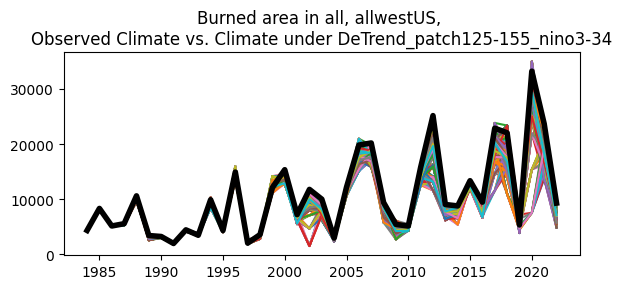

In [41]:
# all data
landname = 'all'
iecoreg = '0'
ecoregname = 'allwestUS'
wumicol = np.array(wumi.loc[:,iecoreg])
tmpdf_3 = wumiallDT.filter(like=ecoregname)
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_3, label='From climate, no SST trend')
#ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

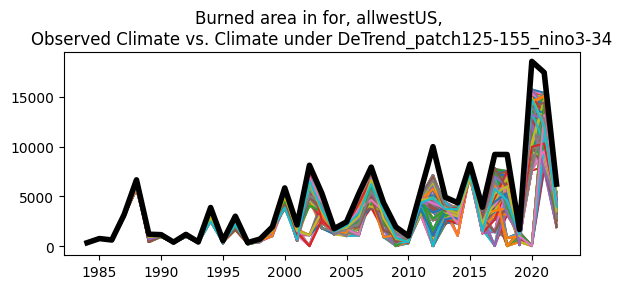

In [42]:
# all data
landname = 'for'
iecoreg = '0'
ecoregname = 'allwestUS'
wumicol = np.array(wumifor.loc[:,iecoreg])
tmpdf_2 = wumiforDT.filter(like=ecoregname)
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_2, label='From climate, no SST trend')
#ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

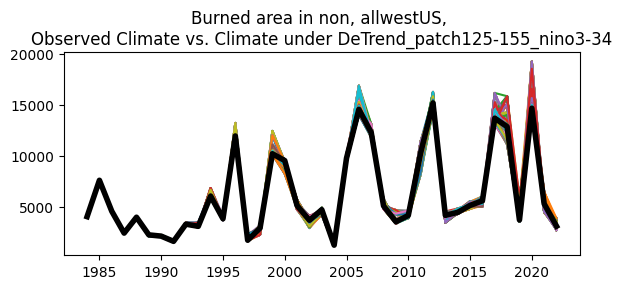

In [43]:
# all data
landname = 'non'
iecoreg = '0'
ecoregname = 'allwestUS'
wumicol = np.array(wuminon.loc[:,iecoreg])
tmpdf_2 = wuminonDT.filter(like=ecoregname)
fig, ax = plt.subplots(figsize=(6,3))
yearxaxis = np.arange(firstyear, finalyear+1)
ax.plot(yearxaxis, wumicol, c='k', label='Observed burned area', linewidth=4, zorder=4)
ax.plot(yearxaxis, tmpdf_2, label='From climate, no SST trend')
#ax.legend()
tmpcorr = pearsonr(burnareapredobs, burnareapred)
ax.set_title('Burned area in '+landname + ', '+ ecoregname+ ', \nObserved Climate vs. Climate under '+ climindnameDT);
fig.tight_layout()
#plt.savefig(figfolder + 'Model_ENSOfull12-2022_'+landname+'_'+ecoregname+'_BurnAreaPred')

In [44]:
# export overwrite
dictoutputs = [dfsstpredBAall, dfsstpredBAfor, dfsstpredBAnon,
               dfclimpredBAall, dfclimpredBAfor, dfclimpredBAnon,
               wumiallDT, wumiforDT, wuminonDT]
dictoutputnames = ['sstpred_all', 'sstpred_for', 'sstpred_non',
                   'climpred_all','climpred_for','climpred_non',
                   'wumiDT_all', 'wumiDT_for', 'wumiDT_non']
# convert to pandas df and export
for i,thisdict in enumerate(dictoutputs):
    tmpoutput = thisdict # select one of the pd dataframes
    if i<3: # export the SST-predicted
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    if (i>=3) & (i<6): # export the climate-predicted
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    if (i>=6): # export the detrended wumi
        filename = predict_string + 'BurnArea_'+dictoutputnames[i]+'_'+climfilename+'_'+str(firstyear)+'-'+str(finalyear)+'.txt'
        tmpoutput.to_csv(filename)
    print('Exported: '+filename)

Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_all_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_for_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_sstpred_non_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_all_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_for_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_climpred_non_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_wumiDT_all_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_wumiDT_for_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


Exported: predicted//patch125-155_nino3-34//BurnArea_wumiDT_non_DeTrendClimObs_patch125-155_nino3-34_1984-2022.txt


In [45]:
# datetime object containing current date and time
from datetime import datetime
now = datetime.now()
# dd/mm/YY H:M:S
dt_string = now.strftime("%d/%m/%Y %H:%M:%S")
print("Model last run =", dt_string)

Model last run = 26/06/2026 14:55:18
